In [ ]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/WorkerSafety25_augmented_5cls_train7654.zip"
)

EXTRACT_DIR = Path("/content/WorkerSafety25_augmented_5cls")

print("ZIP exists:", ZIP_PATH.exists())

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"الملف غير موجود: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print("جاري فك الضغط...")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("تم فك الضغط بنجاح")

for path in EXTRACT_DIR.rglob("images"):
    if path.is_dir():
        print("Images:", path)
        print("Image count:", len(list(path.glob("*"))))

for path in EXTRACT_DIR.rglob("labels"):
    if path.is_dir():
        print("Labels:", path)
        print("Label count:", len(list(path.glob("*.txt"))))

ZIP exists: True
جاري فك الضغط...
تم فك الضغط بنجاح
Images: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/test/images
Image count: 548
Images: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/train/images
Image count: 7654
Images: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/valid/images
Image count: 1093
Labels: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/test/labels
Label count: 548
Labels: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/train/labels
Label count: 7654
Labels: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/valid/labels
Label count: 1093


In [ ]:
yaml_files = list(EXTRACT_DIR.rglob("data.yaml"))

print("ملفات YAML:")
for path in yaml_files:
    print(path)

if not yaml_files:
    raise FileNotFoundError("لم يتم العثور على data.yaml")

ROOT = yaml_files[0].parent
DATASET_DIR = str(ROOT)
DATASET_YAML = str(yaml_files[0])

print("DATASET_DIR:", DATASET_DIR)
print("DATASET_YAML:", DATASET_YAML)

for split in ["train", "valid", "val", "test"]:
    images = ROOT / split / "images"
    labels = ROOT / split / "labels"

    if images.exists() or labels.exists():
        print(
            split,
            "| images:", len(list(images.glob("*"))),
            "| labels:", len(list(labels.glob("*.txt"))),
        )

ملفات YAML:
/content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/data.yaml
DATASET_DIR: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls
DATASET_YAML: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/data.yaml
train | images: 7654 | labels: 7654
valid | images: 1093 | labels: 1093
test | images: 548 | labels: 548


In [ ]:
import os
import torch
from ultralytics import YOLO

print("Ultralytics:", __import__("ultralytics").__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.138
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!find "/content/drive/MyDrive" -iname "data.yaml" -type f | head -20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/WorkerSafety25_clean_5cls_70-20-10.zip"
)
EXTRACT_DIR = Path("/content/WorkerSafety25_clean")

print("ZIP exists:", ZIP_PATH.exists())

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"الملف غير موجود: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print("جاري فك الضغط...")
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

yaml_files = list(EXTRACT_DIR.rglob("data.yaml"))

if not yaml_files:
    raise FileNotFoundError("تم فك الضغط ولكن لم أجد data.yaml")

ROOT = yaml_files[0].parent
DATASET_DIR = str(ROOT)
DATASET_YAML = str(yaml_files[0])

print("تم فك الضغط بنجاح")
print("DATASET_DIR:", DATASET_DIR)
print("DATASET_YAML:", DATASET_YAML)

for split in ["train", "valid", "val", "test"]:
    images_dir = ROOT / split / "images"
    labels_dir = ROOT / split / "labels"

    if images_dir.exists() or labels_dir.exists():
        print(
            split,
            "| images:", len(list(images_dir.glob("*"))),
            "| labels:", len(list(labels_dir.glob("*.txt"))),
        )

ZIP exists: True
جاري فك الضغط...
تم فك الضغط بنجاح
DATASET_DIR: /content/WorkerSafety25_clean/WorkerSafety25_clean_5cls
DATASET_YAML: /content/WorkerSafety25_clean/WorkerSafety25_clean_5cls/data.yaml
train | images: 3827 | labels: 3827
valid | images: 1093 | labels: 1093
test | images: 548 | labels: 548


In [ ]:
MODEL_NAMES = {
    "YOLOv8n": "yolov8n.pt",
    "YOLOv9t": "yolov9t.pt",
    "YOLO26n": "yolo26n.pt"
}
models = {}

for name, weights in MODEL_NAMES.items():
    print(f"Loading {name}...")
    models[name] = YOLO(weights)

print("\nAll models loaded successfully.")

Loading YOLOv8n...
Loading YOLOv9t...
Loading YOLO26n...

All models loaded successfully.


In [ ]:
import yaml

with open(DATASET_YAML, "r") as f:
    data = yaml.safe_load(f)

print("Dataset Classes:")
print(data["names"])
print("Number of Dataset Classes:", len(data["names"]))

Dataset Classes:
{0: 'person', 1: 'hardhat', 2: 'no hardhat', 3: 'safety vest', 4: 'no safety vest'}
Number of Dataset Classes: 5


In [ ]:
EVAL_CONFIG = {
    "data": DATASET_YAML,
    "imgsz": 640,
    "batch": 16,
    "device": 0 if torch.cuda.is_available() else "cpu",
    "split": "test",
    "conf": 0.25
}

print(EVAL_CONFIG)

{'data': '/content/WorkerSafety25_clean/WorkerSafety25_clean_5cls/data.yaml', 'imgsz': 640, 'batch': 16, 'device': 0, 'split': 'test', 'conf': 0.25}


In [ ]:
from pathlib import Path
import shutil
import yaml
from datetime import datetime

ROOT = Path("/content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls")
DRIVE_ROOT = Path("/content/drive/MyDrive")
STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

if not ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {ROOT}")
if not DRIVE_ROOT.exists():
    raise RuntimeError("Google Drive is not mounted")

# Keep data.yaml ready for training in this Colab layout
yaml_path = ROOT / "data.yaml"
with yaml_path.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = str(ROOT)
data_cfg["train"] = "train/images"
data_cfg["val"] = "valid/images"
data_cfg["test"] = "test/images"

with yaml_path.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False, allow_unicode=True)

# Save the cleaned dataset without overwriting any older backup
dest_zip = DRIVE_ROOT / "WorkerSafety25_augmented_5cls_cleaned.zip"
if dest_zip.exists():
    dest_zip = DRIVE_ROOT / f"WorkerSafety25_augmented_5cls_cleaned_{STAMP}.zip"

local_zip = Path(shutil.make_archive(
    "/content/WorkerSafety25_augmented_5cls_cleaned",
    "zip",
    root_dir=ROOT.parent.parent,
    base_dir=ROOT.parent.name,
))
shutil.copy2(local_zip, dest_zip)

# Save the pre-cleanup labels backup
backup_src = Path("/content/labels_backup_before_cleanup")
backup_dest = DRIVE_ROOT / "WorkerSafety25_cleanup_backup" / STAMP
if backup_src.exists():
    shutil.copytree(backup_src, backup_dest, dirs_exist_ok=True)

# All model checkpoints and training logs should be written here
RUNS_DIR = DRIVE_ROOT / "WorkerSafety25_training_runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = DRIVE_ROOT / f"WorkerSafety25_cleanup_summary_{STAMP}.txt"
summary_path.write_text(
    "Removed tiny boxes: 33\n"
    "Clipped outside boxes: 7\n"
    "Changed label files: 29\n"
    "Final audit issues: 0\n"
    f"Cleaned dataset zip: {dest_zip}\n"
    f"Training runs directory: {RUNS_DIR}\n",
    encoding="utf-8",
)

print("SAVED SUCCESSFULLY")
print("Dataset zip:", dest_zip)
print("Size GB:", round(dest_zip.stat().st_size / (1024**3), 3))
print("Labels backup:", backup_dest if backup_src.exists() else "not found")
print("Training runs:", RUNS_DIR)
print("Summary:", summary_path)
from pathlib import Path
from collections import Counter
import cv2
import pandas as pd
import numpy as np
ROOT = Path("/content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls")


CLASS_NAMES = {
    0: "person",
    1: "hardhat",
    2: "no hardhat",
    3: "safety vest",
    4: "no safety vest",
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

issues = []
class_counts = Counter()
split_stats = []

for split in ["train", "valid", "test"]:
    images_dir = ROOT / split / "images"
    labels_dir = ROOT / split / "labels"

    image_paths = [
        p for p in images_dir.rglob("*")
        if p.suffix.lower() in IMAGE_EXTS
    ]

    label_paths = list(labels_dir.rglob("*.txt"))
    image_stems = {p.stem for p in image_paths}
    label_stems = {p.stem for p in label_paths}

    # Labels ليس لها صور
    for stem in sorted(label_stems - image_stems):
        issues.append({
            "split": split,
            "file": stem,
            "line": "",
            "issue": "label_without_image",
            "details": "يوجد label بدون صورة مقابلة",
        })

    split_boxes = 0
    background_images = 0

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"

        image = cv2.imread(str(image_path))
        if image is None:
            issues.append({
                "split": split,
                "file": image_path.name,
                "line": "",
                "issue": "unreadable_image",
                "details": "تعذر فتح الصورة",
            })
            continue

        height, width = image.shape[:2]

        if not label_path.exists():
            issues.append({
                "split": split,
                "file": image_path.name,
                "line": "",
                "issue": "missing_label",
                "details": "الصورة ليس لها ملف txt",
            })
            continue

        lines = [
            line.strip()
            for line in label_path.read_text().splitlines()
            if line.strip()
        ]

        if not lines:
            background_images += 1
            continue

        # اكتشاف السطور المتكررة
        if len(lines) != len(set(lines)):
            issues.append({
                "split": split,
                "file": image_path.name,
                "line": "",
                "issue": "duplicate_box",
                "details": "يوجد Box مكرر بنفس القيم",
            })

        for line_number, line in enumerate(lines, start=1):
            parts = line.split()

            if len(parts) != 5:
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "wrong_columns",
                    "details": f"المفترض 5 قيم، الموجود {len(parts)}",
                })
                continue

            try:
                class_raw, xc, yc, bw, bh = map(float, parts)
            except ValueError:
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "non_numeric",
                    "details": line,
                })
                continue

            values = np.array([class_raw, xc, yc, bw, bh])
            if not np.isfinite(values).all():
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "nan_or_inf",
                    "details": line,
                })
                continue

            class_id = int(class_raw)

            if class_raw != class_id or class_id not in CLASS_NAMES:
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "invalid_class",
                    "details": f"class={class_raw}",
                })
                continue

            if bw <= 0 or bh <= 0:
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "zero_or_negative_box",
                    "details": f"w={bw}, h={bh}",
                })
                continue

            if not (0 <= xc <= 1 and 0 <= yc <= 1 and
                    0 < bw <= 1 and 0 < bh <= 1):
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "not_normalized",
                    "details": f"x={xc}, y={yc}, w={bw}, h={bh}",
                })
                continue

            x1 = xc - bw / 2
            y1 = yc - bh / 2
            x2 = xc + bw / 2
            y2 = yc + bh / 2

            if x1 < -1e-4 or y1 < -1e-4 or x2 > 1.0001 or y2 > 1.0001:
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "box_outside_image",
                    "details": f"x1={x1:.4f}, y1={y1:.4f}, "
                               f"x2={x2:.4f}, y2={y2:.4f}",
                })

            pixel_w = bw * width
            pixel_h = bh * height

            if pixel_w < 3 or pixel_h < 3:
                issues.append({
                    "split": split,
                    "file": image_path.name,
                    "line": line_number,
                    "issue": "very_small_box",
                    "details": f"{pixel_w:.1f}x{pixel_h:.1f} pixels",
                })

            class_counts[(split, class_id)] += 1
            split_boxes += 1

    split_stats.append({
        "split": split,
        "images": len(image_paths),
        "labels": len(label_paths),
        "boxes": split_boxes,
        "background_images": background_images,
        "missing_labels": len(image_stems - label_stems),
        "orphan_labels": len(label_stems - image_stems),
    })

stats_df = pd.DataFrame(split_stats)
issues_df = pd.DataFrame(issues)

counts_df = pd.DataFrame([
    {
        "split": split,
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],
        "boxes": count,
    }
    for (split, class_id), count in sorted(class_counts.items())
])

display(stats_df)
display(counts_df)

print("عدد المشكلات:", len(issues_df))
if len(issues_df):
    display(issues_df["issue"].value_counts())
    display(issues_df.head(100))
    issues_df.to_csv("/content/dataset_issues.csv", index=False)
    print("التقرير محفوظ في: /content/dataset_issues.csv")
else:
    print("لم تُكتشف مشكلات في صيغة وإحداثيات الـBoxes.")

SAVED SUCCESSFULLY
Dataset zip: /content/drive/MyDrive/WorkerSafety25_augmented_5cls_cleaned_20260902_115902.zip
Size GB: 0.82
Labels backup: not found
Training runs: /content/drive/MyDrive/WorkerSafety25_training_runs
Summary: /content/drive/MyDrive/WorkerSafety25_cleanup_summary_20260902_115902.txt


,split,images,labels,boxes,background_images,missing_labels,orphan_labels
0,train,7654,7654,23477,0,0,0
1,valid,1093,1093,3105,0,0,0
2,test,548,548,1521,0,0,0


,split,class_id,class_name,boxes
0,test,0,person,416
1,test,1,hardhat,277
2,test,2,no hardhat,267
3,test,3,safety vest,395
4,test,4,no safety vest,166
5,train,0,person,5922
6,train,1,hardhat,4084
7,train,2,no hardhat,4010
8,train,3,safety vest,6725
9,train,4,no safety vest,2736


عدد المشكلات: 40


,count
issue,
very_small_box,33
box_outside_image,7


,split,file,line,issue,details
0,train,005139_jpg.rf.423fa9e2475ef84d552e989fcf1e99e4...,2,very_small_box,5.0x3.0 pixels
1,train,005139_jpg.rf.423fa9e2475ef84d552e989fcf1e99e4...,4,very_small_box,4.0x3.0 pixels
2,train,Aitin2428_jpg.rf.274c34fcb9e564032f7a3004dc92d...,2,very_small_box,2.0x28.0 pixels
3,train,image_418_jpg.rf.e47fbdf3d40847d34498ceb875b5f...,9,very_small_box,3.0x2.0 pixels
4,train,image_418_jpg.rf.e47fbdf3d40847d34498ceb875b5f...,26,very_small_box,3.0x2.0 pixels
5,train,airport_inside_0090_jpg.rf.228c29de6811d8d7356...,5,very_small_box,2.2x2.2 pixels
6,train,airport_inside_0090_jpg.rf.228c29de6811d8d7356...,6,very_small_box,2.2x2.2 pixels
7,train,Mask2_mov-15_jpg.rf.d625639aa54e35a8055937742a...,1,box_outside_image,"x1=0.0000, y1=0.2520, x2=1.0000, y2=1.0004"
8,train,Aitin2428_jpg.rf.8ad818e70250a0cd0ed72becdd89c...,2,very_small_box,2.0x28.0 pixels
9,train,Aitin2428_jpg.rf.b80ecbb257590f4ded9eb270e9203...,3,very_small_box,2.0x28.0 pixels


التقرير محفوظ في: /content/dataset_issues.csv


In [ ]:
from pathlib import Path
import shutil
import yaml
from datetime import datetime

ROOT = Path("/content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls")
DRIVE_ROOT = Path("/content/drive/MyDrive")
STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

if not ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {ROOT}")
if not DRIVE_ROOT.exists():
    raise RuntimeError("Google Drive is not mounted")

# Keep data.yaml ready for training in this Colab layout
yaml_path = ROOT / "data.yaml"
with yaml_path.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = str(ROOT)
data_cfg["train"] = "train/images"
data_cfg["val"] = "valid/images"
data_cfg["test"] = "test/images"

with yaml_path.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False, allow_unicode=True)

# Save the cleaned dataset without overwriting any older backup
dest_zip = DRIVE_ROOT / "WorkerSafety25_augmented_5cls_cleaned.zip"
if dest_zip.exists():
    dest_zip = DRIVE_ROOT / f"WorkerSafety25_augmented_5cls_cleaned_{STAMP}.zip"

local_zip = Path(shutil.make_archive(
    "/content/WorkerSafety25_augmented_5cls_cleaned",
    "zip",
    root_dir=ROOT.parent.parent,
    base_dir=ROOT.parent.name,
))
shutil.copy2(local_zip, dest_zip)

# Save the pre-cleanup labels backup
backup_src = Path("/content/labels_backup_before_cleanup")
backup_dest = DRIVE_ROOT / "WorkerSafety25_cleanup_backup" / STAMP
if backup_src.exists():
    shutil.copytree(backup_src, backup_dest, dirs_exist_ok=True)

# All model checkpoints and training logs should be written here
RUNS_DIR = DRIVE_ROOT / "WorkerSafety25_training_runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = DRIVE_ROOT / f"WorkerSafety25_cleanup_summary_{STAMP}.txt"
summary_path.write_text(
    "Removed tiny boxes: 33\n"
    "Clipped outside boxes: 7\n"
    "Changed label files: 29\n"
    "Final audit issues: 0\n"
    f"Cleaned dataset zip: {dest_zip}\n"
    f"Training runs directory: {RUNS_DIR}\n",
    encoding="utf-8",
)

print("SAVED SUCCESSFULLY")
print("Dataset zip:", dest_zip)
print("Size GB:", round(dest_zip.stat().st_size / (1024**3), 3))
print("Labels backup:", backup_dest if backup_src.exists() else "not found")
print("Training runs:", RUNS_DIR)
print("Summary:", summary_path)


SAVED SUCCESSFULLY
Dataset zip: /content/drive/MyDrive/WorkerSafety25_augmented_5cls_cleaned_20260902_120014.zip
Size GB: 0.82
Labels backup: not found
Training runs: /content/drive/MyDrive/WorkerSafety25_training_runs
Summary: /content/drive/MyDrive/WorkerSafety25_cleanup_summary_20260902_120014.txt


In [ ]:
from pathlib import Path
import shutil

DRIVE_ROOT = Path("/content/drive/MyDrive")
WEIGHTS_DIR = DRIVE_ROOT / "WorkerSafety25_model_weights"
RUNS_DIR = DRIVE_ROOT / "WorkerSafety25_training_runs"

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

for weight_name in ["yolov8n.pt", "yolov9t.pt", "yolo26n.pt"]:
    src = Path("/content") / weight_name
    dst = WEIGHTS_DIR / weight_name
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)
        print("Saved:", dst)
    elif dst.exists():
        print("Already saved:", dst)
    else:
        print("Will download automatically when training starts:", weight_name)

print("Training outputs folder:", RUNS_DIR)


Already saved: /content/drive/MyDrive/WorkerSafety25_model_weights/yolov8n.pt
Already saved: /content/drive/MyDrive/WorkerSafety25_model_weights/yolov9t.pt
Already saved: /content/drive/MyDrive/WorkerSafety25_model_weights/yolo26n.pt
Training outputs folder: /content/drive/MyDrive/WorkerSafety25_training_runs


In [ ]:
from pathlib import Path
import gc
import torch
from ultralytics import YOLO

DATASET_YAML = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls/data.yaml"
)
WEIGHTS_DIR = Path("/content/drive/MyDrive/WorkerSafety25_model_weights")
RUNS_DIR = Path("/content/drive/MyDrive/WorkerSafety25_training_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {DATASET_YAML}")

# Train only the two remaining models. YOLOv8n is already completed.
MODEL_WEIGHTS = {
    "YOLOv9t": WEIGHTS_DIR / "yolov9t.pt",
    "YOLO26n": WEIGHTS_DIR / "yolo26n.pt",
}

RUN_NAMES = {
    "YOLOv9t": "YOLOv9t-2",
    "YOLO26n": "YOLO26n",
}

TRAIN_CONFIG = {
    "data": str(DATASET_YAML),
    "imgsz": 800,
    "epochs": 60,
    "patience": 15,
    "batch": 16,
    "device": 0,
    "workers": 2,
    "project": str(RUNS_DIR),
    "pretrained": True,
    "amp": True,
    "seed": 42,
    "deterministic": True,
    "save": True,
    "save_period": 5,
    "plots": True,
    "close_mosaic": 10,
    "verbose": True,
}

print("Dataset:", DATASET_YAML)
print("Training outputs:", RUNS_DIR)
print("Mode: Full fine-tuning (all layers trainable)")
print("Remaining models:", list(MODEL_WEIGHTS))

for model_name, weights_path in MODEL_WEIGHTS.items():
    run_name = RUN_NAMES[model_name]
    best_path = RUNS_DIR / run_name / "weights" / "best.pt"

    if best_path.exists():
        print(f"Skipping {model_name}: already completed at {best_path}")
        continue

    if not weights_path.exists():
        raise FileNotFoundError(f"Missing weights: {weights_path}")

    print(f"\n{'=' * 70}")
    print(f"Starting {model_name} -> {run_name}")
    print(f"{'=' * 70}")

    model = YOLO(str(weights_path))
    results = model.train(
        **TRAIN_CONFIG,
        name=run_name,
        freeze=None,
        exist_ok=True,
    )

    print(f"Completed {model_name}")
    del model, results
    gc.collect()
    torch.cuda.empty_cache()

print("\nBoth remaining models completed.")
WEIGHTS_DIR = Path("/content/drive/MyDrive/WorkerSafety25_model_weights")
RUNS_DIR = Path("/content/drive/MyDrive/WorkerSafety25_training_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {DATASET_YAML}")

MODEL_WEIGHTS = {
    "YOLOv8n": WEIGHTS_DIR / "yolov8n.pt",
    "YOLOv9t": WEIGHTS_DIR / "yolov9t.pt",
    "YOLO26n": WEIGHTS_DIR / "yolo26n.pt",
}

TRAIN_CONFIG = {
    "data": str(DATASET_YAML),
    "imgsz": 800,
    "epochs": 60,
    "patience": 15,
    "batch": 16,
    "device": 0,
    "workers": 2,
    "project": str(RUNS_DIR),
    "pretrained": True,
    "amp": True,
    "seed": 42,
    "deterministic": True,
    "save": True,
    "save_period": 5,
    "plots": True,
    "close_mosaic": 10,
    "verbose": True,
}

print("Dataset:", DATASET_YAML)
print("Training outputs:", RUNS_DIR)
print("Mode: Full fine-tuning (all layers trainable)")
print("Models will train sequentially:", list(MODEL_WEIGHTS))

for run_name, weights_path in MODEL_WEIGHTS.items():
    if not weights_path.exists():
        raise FileNotFoundError(f"Missing weights: {weights_path}")

    print(f"\n{'=' * 70}")
    print(f"Starting {run_name}")
    print(f"{'=' * 70}")

    model = YOLO(str(weights_path))
    results = model.train(
        **TRAIN_CONFIG,
        name=run_name,
        freeze=None,
    )

    print(f"Completed {run_name}")
    del model, results
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll three models completed.")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Dataset: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/data.yaml
Training outputs: /content/drive/MyDrive/WorkerSafety25_training_runs
Mode: Full fine-tuning (all layers trainable)
Remaining models: ['YOLOv9t', 'YOLO26n']

Starting YOLOv9t -> YOLOv9t-2
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cu

Exception ignored in atexit callback <function _exit_function at 0x7ab795b7b060>Exception ignored in atexit callback <function _exit_function at 0x7ab795b7b060>:
:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/util.py", line 431, in _exit_function
  File "/usr/lib/python3.13/multiprocessing/util.py", line 431, in _exit_function
        _run_finalizers()_run_finalizers()

  File "/usr/lib/python3.13/multiprocessing/util.py", line 371, in _run_finalizers
  File "/usr/lib/python3.13/multiprocessing/util.py", line 371, in _run_finalizers
        finalizer()finalizer()

KeyboardInterruptres = self._callback(*self._args, **self._kwargs)  File "/usr/lib/python3.13/multiprocessing/util.py", line 295, in __call__
:     

  File "/usr/lib/python3.13/multiprocessing/queues.py", line 217, in _finalize_join
    thread.join()
  File "/usr/lib/python3.13/threading.py", line 1095, in join
    self._handle.join(timeout)
KeyboardInterru

       1/60      4.04G      1.385      3.471      1.724         78        800: 28% ━━━───────── 135/479 4.8it/s 29.5s<1:12


KeyboardInterrupt: 

In [ ]:
!pip install -q -U ultralytics

from google.colab import drive
from pathlib import Path
import zipfile

drive.mount("/content/drive")

ZIP_PATH = Path(
    "/content/drive/MyDrive/"
    "WorkerSafety25_augmented_5cls_cleaned.zip"
)

DATASET_YAML = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls/data.yaml"
)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

if not DATASET_YAML.exists():
    print("جاري استخراج البيانات...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
               zip_file.extractall("/content")
    print("تم استخراج البيانات")

print("Ultralytics installed")
print("Dataset ready:", DATASET_YAML.exists())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.4 MB/s eta 0:00:00
Mounted at /content/drive
جاري استخراج البيانات...
تم استخراج البيانات
Ultralytics installed
Dataset ready: True


In [ ]:
from pathlib import Path
from collections import Counter
import pandas as pd

ROOT = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls"
)

CLASS_NAMES = {
    0: "person",
    1: "hardhat",
    2: "no hardhat",
    3: "safety vest",
    4: "no safety vest"
}

rows = []

for split in ["train", "valid", "test"]:
    labels_dir = ROOT / split / "labels"

    box_counts = Counter()
    image_counts = Counter()

    for label_file in labels_dir.glob("*.txt"):
        classes_in_image = set()

        for line in label_file.read_text().splitlines():
            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))
            box_counts[class_id] += 1
            classes_in_image.add(class_id)

        for class_id in classes_in_image:
            image_counts[class_id] += 1

    for class_id, class_name in CLASS_NAMES.items():
        rows.append({
            "split": split,
            "class_id": class_id,
            "class_name": class_name,
            "boxes": box_counts[class_id],
            "images_containing_class": image_counts[class_id]
        })

counts_df = pd.DataFrame(rows)
display(counts_df)

print("\nالفئتان المطلوب فحصهما:")
display(
    counts_df[
        counts_df["class_name"].isin(["hardhat", "no safety vest"])
    ]
)

,split,class_id,class_name,boxes,images_containing_class
0,train,0,person,5915,4016
1,train,1,hardhat,4072,2986
2,train,2,no hardhat,3998,2813
3,train,3,safety vest,6725,4130
4,train,4,no safety vest,2736,1672
5,valid,0,person,792,572
6,valid,1,hardhat,512,405
7,valid,2,no hardhat,571,418
8,valid,3,safety vest,856,600
9,valid,4,no safety vest,373,227



الفئتان المطلوب فحصهما:


,split,class_id,class_name,boxes,images_containing_class
1,train,1,hardhat,4072,2986
4,train,4,no safety vest,2736,1672
6,valid,1,hardhat,512,405
9,valid,4,no safety vest,373,227
11,test,1,hardhat,277,205
14,test,4,no safety vest,166,116


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls"
)

TARGET_CLASSES = {
    1: "hardhat",
    4: "no safety vest"
}

records = []

for split in ["train", "valid", "test"]:
    labels_dir = ROOT / split / "labels"

    for label_file in labels_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))

            if class_id not in TARGET_CLASSES:
                continue

            _, _, _, w, h = map(float, parts)

            # الحجم التقريبي عند التدريب على imgsz=800
            width_px = w * 800
            height_px = h * 800

            records.append({
                "split": split,
                "class_name": TARGET_CLASSES[class_id],
                "width_px": width_px,
                "height_px": height_px,
                "area_px": width_px * height_px,
                "smallest_side": min(width_px, height_px)
            })

sizes_df = pd.DataFrame(records)

size_summary = (
    sizes_df.groupby(["split", "class_name"])
    .agg(
        boxes=("class_name", "size"),
        median_width=("width_px", "median"),
        median_height=("height_px", "median"),
        median_area=("area_px", "median"),
        under_16px=("smallest_side", lambda x: (x < 16).mean() * 100),
        under_32px=("smallest_side", lambda x: (x < 32).mean() * 100)
    )
    .round(2)
    .reset_index()
)

display(size_summary)

,split,class_name,boxes,median_width,median_height,median_area,under_16px,under_32px
0,test,hardhat,277,105.00,132.13,13528.12,5.78,9.75
1,test,no safety vest,166,170.99,266.36,49697.29,0.60,9.64
2,train,hardhat,4072,100.00,124.78,12262.50,4.54,11.30
3,train,no safety vest,2736,139.20,219.87,30565.12,4.71,11.40
4,valid,hardhat,512,106.88,133.12,13784.38,5.08,7.62
5,valid,no safety vest,373,144.33,224.00,34112.42,4.02,6.43


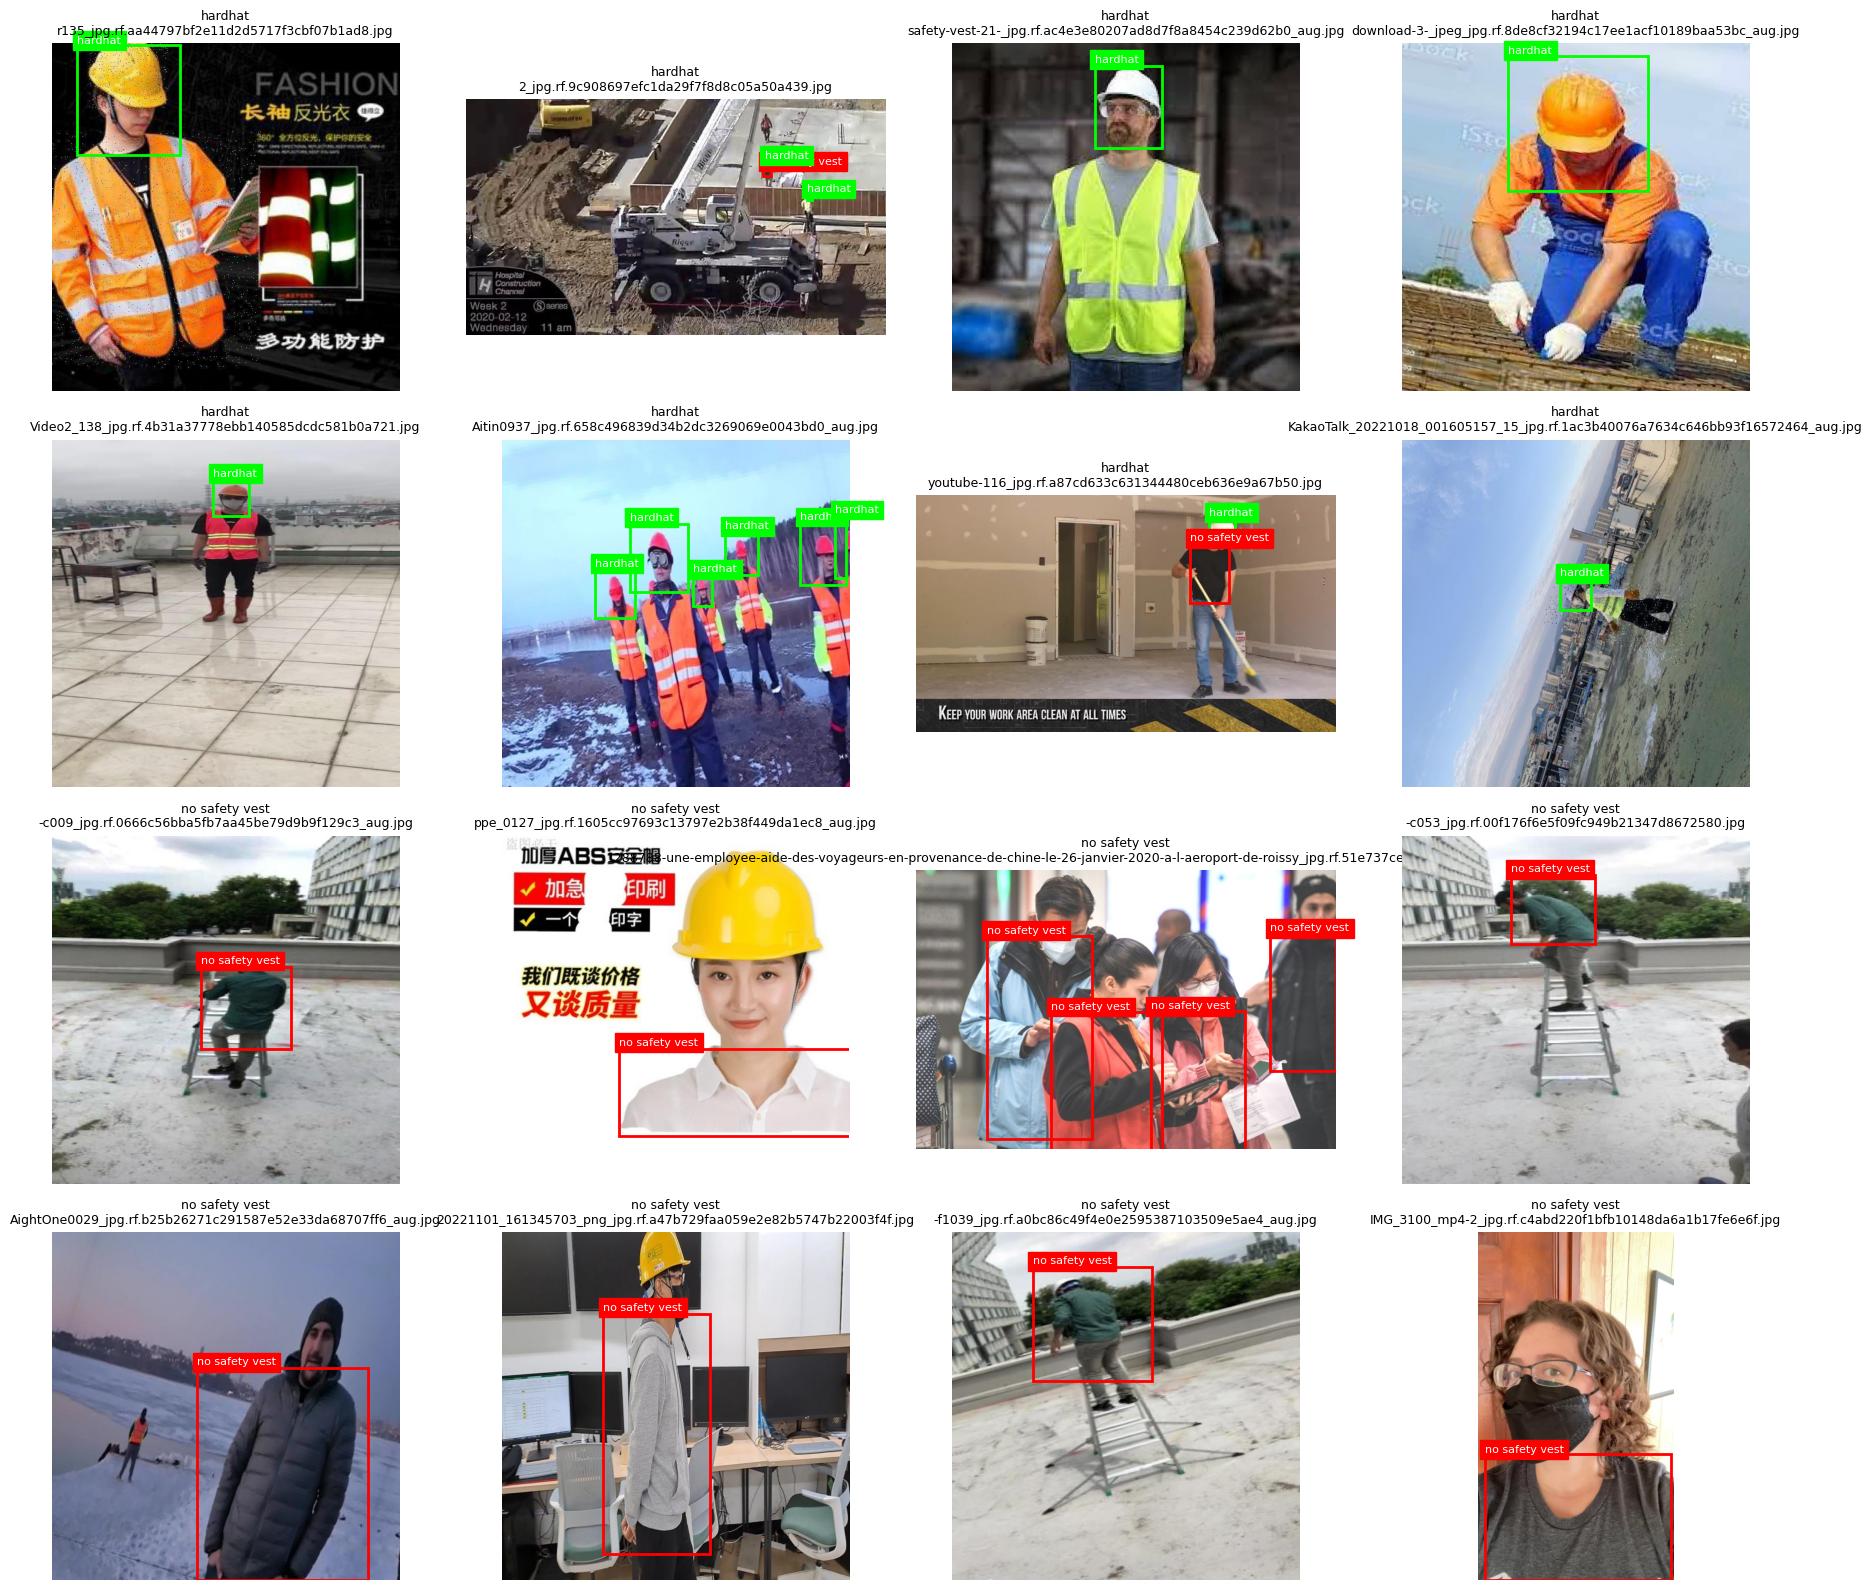

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

ROOT = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls"
)

TARGET_CLASSES = {
    1: "hardhat",
    4: "no safety vest"
}

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
random.seed(42)

def find_image(images_dir, stem):
    for extension in IMAGE_EXTENSIONS:
        image_path = images_dir / f"{stem}{extension}"
        if image_path.exists():
            return image_path
    return None

selected = []

for target_id, target_name in TARGET_CLASSES.items():
    labels_dir = ROOT / "train" / "labels"
    images_dir = ROOT / "train" / "images"
    candidates = []

    for label_path in labels_dir.glob("*.txt"):
        lines = label_path.read_text().splitlines()

        if any(
            len(line.split()) == 5
            and int(float(line.split()[0])) == target_id
            for line in lines
        ):
            candidates.append(label_path)

    for label_path in random.sample(candidates, min(8, len(candidates))):
        selected.append((target_id, target_name, label_path, images_dir))

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for ax, (target_id, target_name, label_path, images_dir) in zip(axes, selected):
    image_path = find_image(images_dir, label_path.stem)

    if image_path is None:
        ax.axis("off")
        continue

    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    ax.imshow(image)

    for line in label_path.read_text().splitlines():
        parts = line.split()

        if len(parts) != 5:
            continue

        class_id, xc, yc, bw, bh = map(float, parts)
        class_id = int(class_id)

        # نعرض فقط الفئتين محل الفحص
        if class_id not in TARGET_CLASSES:
            continue

        x = (xc - bw / 2) * width
        y = (yc - bh / 2) * height
        box_width = bw * width
        box_height = bh * height

        color = "lime" if class_id == 1 else "red"

        rectangle = patches.Rectangle(
            (x, y),
            box_width,
            box_height,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rectangle)
        ax.text(
            x,
            max(0, y - 5),
            TARGET_CLASSES[class_id],
            color="white",
            backgroundcolor=color,
            fontsize=8
        )

    ax.set_title(f"{target_name}\n{image_path.name}", fontsize=9)
    ax.axis("off")

for ax in axes[len(selected):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from datetime import datetime
from ultralytics import YOLO
import pandas as pd

BEST_MODEL = Path(
    "/content/drive/MyDrive/WorkerSafety25_training_runs/"
    "YOLOv8n-2/weights/best.pt"
)

DATASET_YAML = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls/data.yaml"
)

TEST_IMAGES = DATASET_YAML.parent / "test/images"

TEST_DIR = (
    Path("/content/drive/MyDrive/WorkerSafety25_test_results")
    / datetime.now().strftime("%Y%m%d_%H%M%S")
)

TEST_DIR.mkdir(parents=True, exist_ok=True)

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"Model not found: {BEST_MODEL}")

if not DATASET_YAML.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_YAML}")

model = YOLO(str(BEST_MODEL))

# حساب نتائج الاختبار
metrics = model.val(
    data=str(DATASET_YAML),
    split="test",
    imgsz=800,
    batch=16,
    device=0,
    plots=True,
    project=str(TEST_DIR),
    name="metrics",
    exist_ok=True
)

summary = pd.DataFrame([{
    "model": "YOLOv8n",
    "precision": metrics.box.mp,
    "recall": metrics.box.mr,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
}])

display(summary)

summary.to_csv(
    TEST_DIR / "metrics_summary.csv",
    index=False
)

# حفظ صور الاختبار وعليها البوكسات
model.predict(
    source=str(TEST_IMAGES),
    imgsz=800,
    conf=0.25,
    device=0,
    save=True,
    project=str(TEST_DIR),
    name="predictions",
    exist_ok=True,
    verbose=False
)

print("تم الاختبار بنجاح")
print("النتائج والصور محفوظة في:", TEST_DIR)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1790.8±417.3 MB/s, size: 56.0 KB)
val: Scanning /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/test/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 1.4Kit/s 0.4s
val: New cache created: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 6.8it/s 5.2s
               

,model,precision,recall,mAP50,mAP50-95
0,YOLOv8n,0.869763,0.840538,0.860408,0.620129


Results saved to /content/drive/MyDrive/WorkerSafety25_test_results/20260902_133544/predictions
تم الاختبار بنجاح
النتائج والصور محفوظة في: /content/drive/MyDrive/WorkerSafety25_test_results/20260902_133544


In [ ]:
from pathlib import Path
import gc
import torch
from ultralytics import YOLO

DATASET_YAML = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls/data.yaml"
)

WEIGHTS_DIR = Path(
    "/content/drive/MyDrive/WorkerSafety25_model_weights"
)

RUNS_DIR = Path(
    "/content/drive/MyDrive/WorkerSafety25_training_runs"
)

RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_YAML.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found: {DATASET_YAML}"
    )

# النموذجان المتبقيان فقط
MODELS = {
    "YOLOv9t": {
        "weights": WEIGHTS_DIR / "yolov9t.pt",
        "run_name": "YOLOv9t-2",
    },
    "YOLO26n": {
        "weights": WEIGHTS_DIR / "yolo26n.pt",
        "run_name": "YOLO26n",
    },
}

TRAIN_CONFIG = {
    "data": str(DATASET_YAML),
    "imgsz": 800,
    "epochs": 60,
    "patience": 15,
    "batch": 16,
    "device": 0,
    "workers": 2,
    "project": str(RUNS_DIR),
    "pretrained": True,
    "amp": True,
    "seed": 42,
    "deterministic": True,
    "save": True,
    "save_period": 5,
    "plots": True,
    "close_mosaic": 10,
    "verbose": True,
}

print("سيتم تدريب:", list(MODELS))
print("لن تتم إعادة تدريب YOLOv8n")

for model_name, config in MODELS.items():
    weights_path = config["weights"]
    run_name = config["run_name"]
    best_path = RUNS_DIR / run_name / "weights" / "best.pt"

    # يمنع إعادة تدريب أي نموذج مكتمل
    if best_path.exists():
        print(f"تخطي {model_name}: النموذج مكتمل ومحفوظ في:")
        print(best_path)
        continue

    if not weights_path.exists():
        raise FileNotFoundError(
            f"Pretrained weights not found: {weights_path}"
        )

    print("\n" + "=" * 70)
    print(f"بدء تدريب {model_name}")
    print("=" * 70)

    model = YOLO(str(weights_path))

    results = model.train(
        **TRAIN_CONFIG,
        name=run_name,
        freeze=None,
        exist_ok=True,
    )

    print(f"اكتمل تدريب {model_name}")

    del model, results
    gc.collect()
    torch.cuda.empty_cache()

print("\nاكتمل تدريب النموذجين المتبقيين")

سيتم تدريب: ['YOLOv9t', 'YOLO26n']
لن تتم إعادة تدريب YOLOv8n

بدء تدريب YOLOv9t
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rat

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/WorkerSafety25_training_runs/"
    "YOLOv8n-2/weights/best.pt"
)

metrics = model.val(
    data="/content/WorkerSafety25_augmented_5cls/"
         "WorkerSafety25_augmented_5cls/data.yaml",
    split="test",
    imgsz=800,
    batch=16,
    device=0,
    plots=True,
    project="/content/drive/MyDrive/WorkerSafety25_test_results",
    name="YOLOv8n_test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

In [ ]:
from pathlib import Path
import shutil
import cv2

ROOT = Path("/content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls")
BACKUP = Path("/content/labels_backup_before_cleanup")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

removed_small = 0
clipped_outside = 0
changed_files = 0

for split in ["train", "valid", "test"]:
    images_dir = ROOT / split / "images"
    labels_dir = ROOT / split / "labels"

    images_by_stem = {
        p.stem: p
        for p in images_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    }

    for label_path in labels_dir.glob("*.txt"):
        image_path = images_by_stem.get(label_path.stem)
        if image_path is None:
            continue

        image = cv2.imread(str(image_path))
        if image is None:
            continue

        height, width = image.shape[:2]
        original_lines = [
            line.strip()
            for line in label_path.read_text().splitlines()
            if line.strip()
        ]

        cleaned_lines = []
        changed = False

        for line in original_lines:
            parts = line.split()
            if len(parts) != 5:
                cleaned_lines.append(line)
                continue

            try:
                class_id, xc, yc, bw, bh = map(float, parts)
            except ValueError:
                cleaned_lines.append(line)
                continue

            pixel_w = bw * width
            pixel_h = bh * height

            if pixel_w < 3 or pixel_h < 3:
                removed_small += 1
                changed = True
                continue

            x1 = xc - bw / 2
            y1 = yc - bh / 2
            x2 = xc + bw / 2
            y2 = yc + bh / 2

            if x1 < -1e-4 or y1 < -1e-4 or x2 > 1.0001 or y2 > 1.0001:
                x1 = min(1.0, max(0.0, x1))
                y1 = min(1.0, max(0.0, y1))
                x2 = min(1.0, max(0.0, x2))
                y2 = min(1.0, max(0.0, y2))

                xc = (x1 + x2) / 2
                yc = (y1 + y2) / 2
                bw = x2 - x1
                bh = y2 - y1

                line = f"{int(class_id)} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
                clipped_outside += 1
                changed = True

            cleaned_lines.append(line)

        if changed:
            backup_path = BACKUP / split / label_path.name
            backup_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(label_path, backup_path)

            text = "\n".join(cleaned_lines)
            label_path.write_text(text + ("\n" if text else ""))
            changed_files += 1

print("Cleanup complete")
print("Removed tiny boxes:", removed_small)
print("Clipped outside boxes:", clipped_outside)
print("Changed label files:", changed_files)
print("Backup:", BACKUP)


Cleanup complete
Removed tiny boxes: 0
Clipped outside boxes: 0
Changed label files: 0
Backup: /content/labels_backup_before_cleanup


In [ ]:
from pathlib import Path
from ultralytics import YOLO
import pandas as pd
import torch
import gc

DATASET_YAML = Path(
    "/content/WorkerSafety25_augmented_5cls/"
    "WorkerSafety25_augmented_5cls/data.yaml"
)

MODEL_PATHS = {
    "YOLOv8n": Path(
        "/content/drive/MyDrive/WorkerSafety25_training_runs/"
        "YOLOv8n-2/weights/best.pt"
    ),
    "YOLOv9t": Path(
        "/content/drive/MyDrive/WorkerSafety25_training_runs/"
        "YOLOv9t-2/weights/best.pt"
    ),
    "YOLO26n": Path(
        "/content/drive/MyDrive/WorkerSafety25_training_runs/"
        "YOLO26n/weights/best.pt"
    ),
}

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/WorkerSafety25_final_comparison"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_YAML.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_YAML}"
    )

for name, path in MODEL_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(
            f"{name} model not found: {path}"
        )

overall_results = []
class_results = []

for model_name, model_path in MODEL_PATHS.items():

    print("\n" + "=" * 70)
    print(f"اختبار {model_name}")
    print("=" * 70)

    model = YOLO(str(model_path))

    metrics = model.val(
        data=str(DATASET_YAML),
        split="test",
        imgsz=800,
        batch=16,
        device=0,
        plots=True,
        project=str(OUTPUT_DIR),
        name=model_name,
        exist_ok=True,
    )

    overall_results.append({
        "model": model_name,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    })

    # نتائج كل فئة بشكل مستقل
    for class_id, class_name in model.names.items():
        class_results.append({
            "model": model_name,
            "class_id": int(class_id),
            "class_name": class_name,
            "precision": float(metrics.box.p[class_id]),
            "recall": float(metrics.box.r[class_id]),
            "mAP50": float(metrics.box.ap50[class_id]),
            "mAP50-95": float(metrics.box.maps[class_id]),
        })

    del model, metrics
    gc.collect()
    torch.cuda.empty_cache()

# النتائج العامة
summary_df = pd.DataFrame(overall_results)
summary_df = summary_df.sort_values(
    "mAP50-95",
    ascending=False
).reset_index(drop=True)

# نتائج الفئات
classes_df = pd.DataFrame(class_results)
classes_df = classes_df.sort_values(
    ["model", "class_id"]
).reset_index(drop=True)

print("\nالنتائج العامة:")
display(summary_df)

print("\nنتائج كل فئة:")
display(classes_df)

summary_df.to_csv(
    OUTPUT_DIR / "overall_comparison.csv",
    index=False
)

classes_df.to_csv(
    OUTPUT_DIR / "per_class_comparison.csv",
    index=False
)

winner = summary_df.iloc[0]

print("\n" + "=" * 70)
print("أفضل نموذج:", winner["model"])
print("Precision:", round(winner["precision"], 4))
print("Recall:", round(winner["recall"], 4))
print("mAP50:", round(winner["mAP50"], 4))
print("mAP50-95:", round(winner["mAP50-95"], 4))
print("=" * 70)

print("\nتم حفظ النتائج في:")
print(OUTPUT_DIR)


اختبار YOLOv8n
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1559.0±564.0 MB/s, size: 52.3 KB)
val: Scanning /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/test/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 1.5Kit/s 0.4s
val: New cache created: /content/WorkerSafety25_augmented_5cls/WorkerSafety25_augmented_5cls/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 8.0it/s 4.4s
                   all        548       1520       0.87      0.841       0.86       0.62
                person        294        415      0.933      0.812      0.889      0.735
               hardhat        205        277      0.816      0.726      0.771       0.48
            no hardhat        207        2

,model,precision,recall,mAP50,mAP50-95
0,YOLOv9t,0.833916,0.821835,0.850113,0.622660
1,YOLO26n,0.853581,0.810885,0.852460,0.620500
2,YOLOv8n,0.869763,0.840538,0.860408,0.620129



نتائج كل فئة:


,model,class_id,class_name,precision,recall,mAP50,mAP50-95
0,YOLO26n,0,person,0.909947,0.779150,0.874990,0.730761
1,YOLO26n,1,hardhat,0.791840,0.727844,0.763291,0.476355
2,YOLO26n,2,no hardhat,0.887070,0.827715,0.893650,0.607087
3,YOLO26n,3,safety vest,0.954983,0.966704,0.979659,0.877441
4,YOLO26n,4,no safety vest,0.724067,0.753012,0.750711,0.410853
5,YOLOv8n,0,person,0.932798,0.812048,0.889351,0.735449
6,YOLOv8n,1,hardhat,0.816010,0.725632,0.770861,0.479958
7,YOLOv8n,2,no hardhat,0.879662,0.876404,0.891614,0.613948
8,YOLOv8n,3,safety vest,0.970191,0.974684,0.982817,0.876983
9,YOLOv8n,4,no safety vest,0.750153,0.813920,0.767395,0.394307



أفضل نموذج: YOLOv9t
Precision: 0.8339
Recall: 0.8218
mAP50: 0.8501
mAP50-95: 0.6227

تم حفظ النتائج في:
/content/drive/MyDrive/WorkerSafety25_final_comparison
